In [1]:
print("Hello, World!")

Hello, World!


## Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [3]:
df = pd.read_csv('Customer Data.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Exploratory Data Analysis

In [4]:
df.shape

(8950, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

** As CUST_ID is not necessary in our model building we can remove this column

In [6]:
df = df.drop(['CUST_ID'], axis=1)

In [7]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [8]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

- As CREDIT_LIMIT has only one null value we can simply remove the record
- And for MINIMUM_PAYMENTS more than 300 records are there so we can impute it replacing with mean of the MINIMUM_PAYMENTS.


In [9]:
df.dropna(subset=["CREDIT_LIMIT"], inplace=True)
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].mean())

df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

- Checking if there are any duplicate rows in it or not

In [10]:
df.duplicated().sum()

np.int64(0)

## Data Distribution Analysis
Analyzing the distributions and spread of each numerical feature to assess skewness and identify potential outliers.

## Distribution Summary — Key Observations

### BALANCE
> **Meaning:** The amount of money a customer currently owes on their credit card (unpaid balance).
- Strongly **right-skewed** — the majority of customers maintain a **low balance** (close to zero), while a small subset carries very high unpaid balances.
- Presence of heavy outliers at the upper end suggests a group of **high-debt revolvers** who rely on credit heavily.

### BALANCE_FREQUENCY
> **Meaning:** How often the balance is updated — a score from 0 to 1 (1 = updated every month).
- Shows a clear **bimodal pattern** — most values cluster near **0 or 1**, indicating customers either update their balance almost every month (frequent users) or rarely at all (inactive users).
- Very few customers fall in the middle range, confirming a distinct behavioral divide.

### PURCHASES
> **Meaning:** Total amount spent on purchases made using the credit card.
- Strongly **right-skewed** with a large spike at **zero** — a significant portion of customers make **no purchases** at all.
- A long right tail shows a small group of high-spending customers, likely prime candidates for rewards or premium segments.

### ONEOFF_PURCHASES
> **Meaning:** Total amount spent on single large purchases (one-time transactions, not split into installments).
- Extremely **right-skewed** with the majority at **zero** — most customers do not make large one-off (single) purchases.
- The heavy tail represents occasional big spenders, possibly buying high-value items infrequently.

### INSTALLMENTS_PURCHASES
> **Meaning:** Total amount spent on purchases paid in installments (EMI / split payments).
- **Right-skewed** with a large zero-concentration — many customers avoid installment buying.
- A moderate tail suggests a segment that **prefers EMI-style purchases**, likely for larger goods.

### CASH_ADVANCE
> **Meaning:** Amount of cash withdrawn in advance using the credit card (like a short-term loan).
- Severely **right-skewed** with most customers at **zero** — the majority never take cash advances.
- Extreme outliers in the upper tail represent **high-risk customers** who routinely use the credit card as a cash source, incurring high fees.

### PURCHASES_FREQUENCY
> **Meaning:** How regularly purchases are made — a score from 0 to 1 (1 = purchases made every month).
- **Bimodal** — strong peaks at both **0** (never purchase) and **1** (purchase every month), with relatively few customers in between.
- This cleanly separates **active purchasers** from **inactive cardholders**.

### ONEOFF_PURCHASES_FREQUENCY
> **Meaning:** How often one-off (single large) purchases are made — a score from 0 to 1.
- **Right-skewed with a dominant zero peak** — most customers never make one-off purchases in a given month.
- A secondary bump near 1.0 indicates a small group of consistent single-purchase users.

### PURCHASES_INSTALLMENTS_FREQUENCY
> **Meaning:** How often installment purchases are made — a score from 0 to 1.
- **Bimodal** — customers are split between those who **never** use installments and those who use them **regularly every month**.
- Indicates a clear preference-based segmentation opportunity.

### CASH_ADVANCE_FREQUENCY
> **Meaning:** How often cash advances are taken — a score from 0 to 1.
- Heavily **right-skewed** — most customers have a frequency of **zero**, meaning cash advances are rare behavior.
- Small but consistent non-zero values highlight a niche **cash-dependent segment**.

### CASH_ADVANCE_TRX
> **Meaning:** Number of individual cash advance transactions made.
- **Right-skewed count variable** — most customers have **zero transactions**, confirming cash advance is not mainstream behavior.
- Outliers with high transaction counts are likely **high-risk or financially stressed** customers.

### PURCHASES_TRX
> **Meaning:** Number of individual purchase transactions made.
- **Right-skewed** but with a smoother distribution than cash advance — some customers are moderately active.
- A long tail of high transaction counts suggests a **frequent buyer segment** that could benefit from loyalty programs.

### CREDIT_LIMIT
> **Meaning:** The maximum credit amount the bank has approved for the customer.
- **Right-skewed** with visible **spikes at round numbers** (e.g., 1000, 2000, 5000) due to discretized limit assignments by banks.
- Most customers have moderate limits; very few have extremely high limits.

### PAYMENTS
> **Meaning:** Total amount paid by the customer to the bank (repayments made).
- Strongly **right-skewed** — most payments are small, but outliers show customers making very large repayments, possibly those with high balances.
- Distribution mirrors BALANCE, consistent with customers paying proportionally to what they owe.

### MINIMUM_PAYMENTS
> **Meaning:** The minimum required payment amount due each month (set by the bank).
- Strongly **right-skewed** — most customers pay small minimum amounts, but a tail of high values reflects customers with very large outstanding debts.
- Had **313 missing values**, imputed with the column mean — meaning the distribution is slightly compressed around the mean after imputation.

### PRC_FULL_PAYMENT
> **Meaning:** Percentage of months where the customer paid the full outstanding balance (0 = never, 1 = always).
- Heavily **right-skewed with a dominant zero peak** — the vast majority of customers **never pay their full balance**, carrying debt forward each month.
- A small cluster near **1.0** represents disciplined **transactor customers** who consistently pay off their balance in full.

### TENURE
> **Meaning:** Number of months the customer has held the credit card account.
- Strongly **left-skewed (negatively skewed)** — the overwhelming majority of customers have a tenure of **12 months** (the maximum in the dataset).
- Very few customers have short tenures, indicating this dataset largely captures **established, long-term cardholders**.

### 1. Histograms with Kernel Density Estimation (KDE)

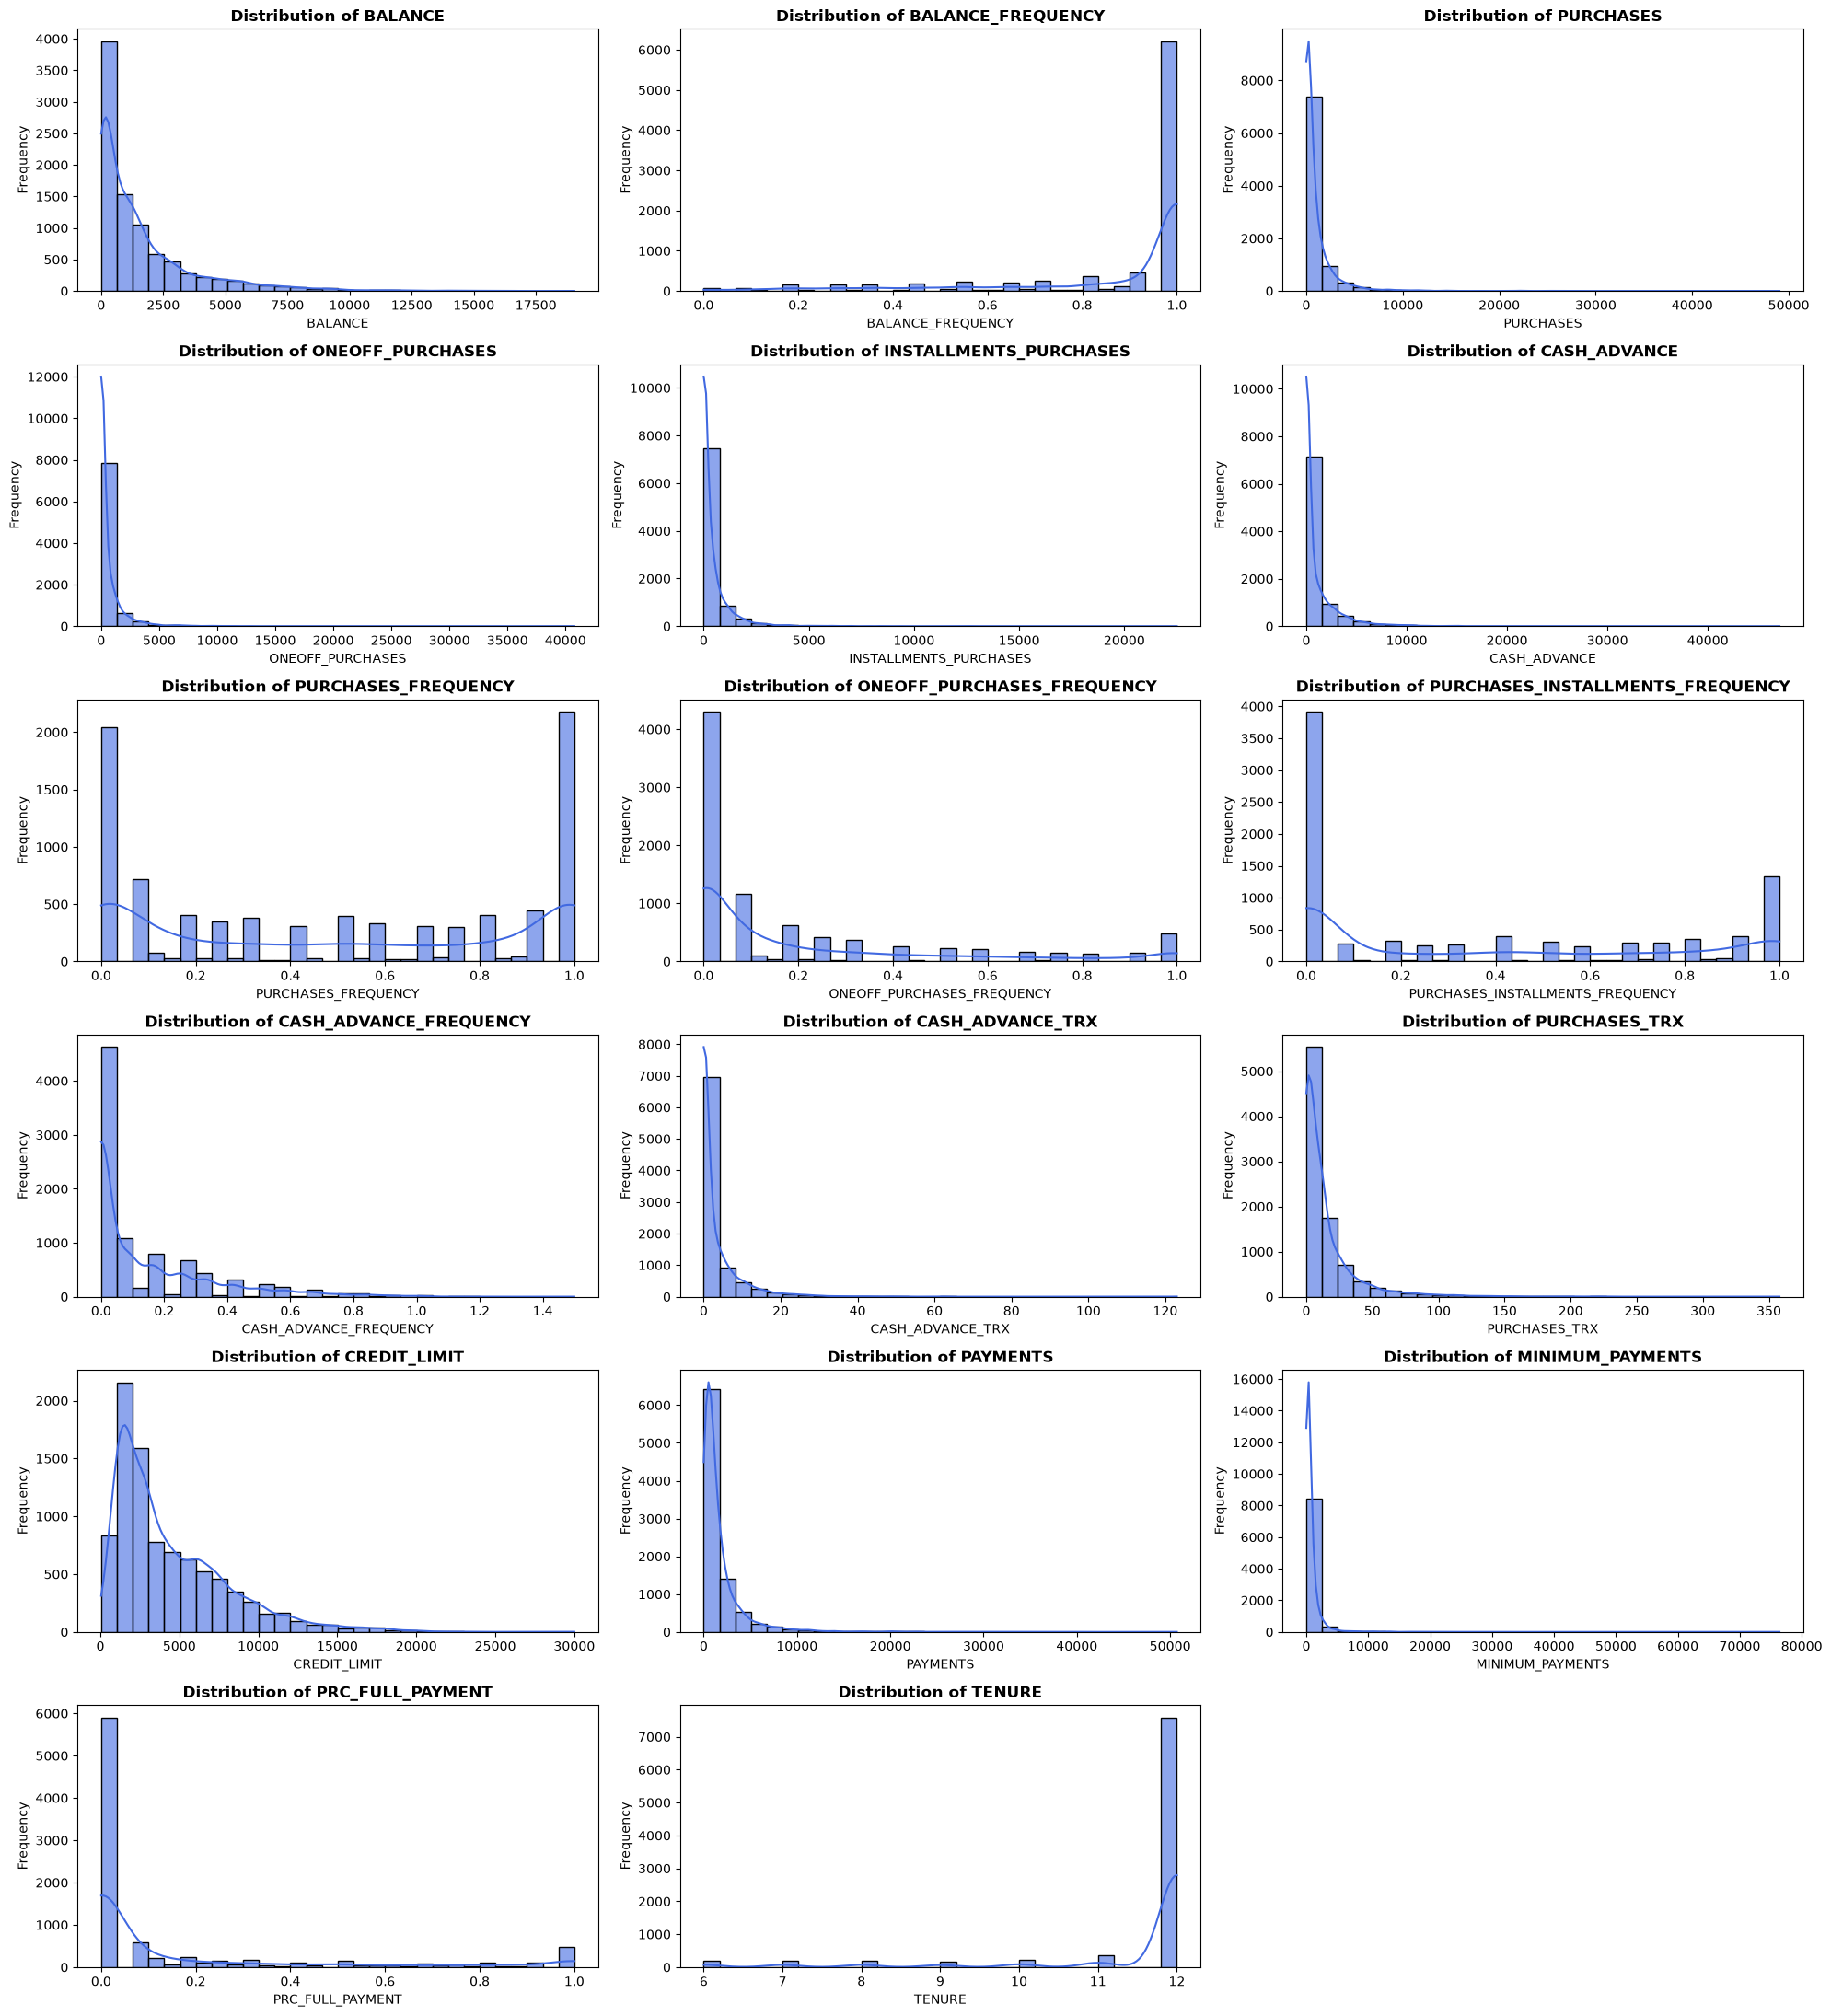

In [11]:
# Distribution plots (Histogram + KDE) for all numerical features
plt.figure(figsize=(20, 22))
cols = df.columns

for i, col in enumerate(cols, 1):
    plt.subplot(6, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='royalblue', edgecolor='black', alpha=0.6)
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

### 2. Box Plots for Outlier Detection

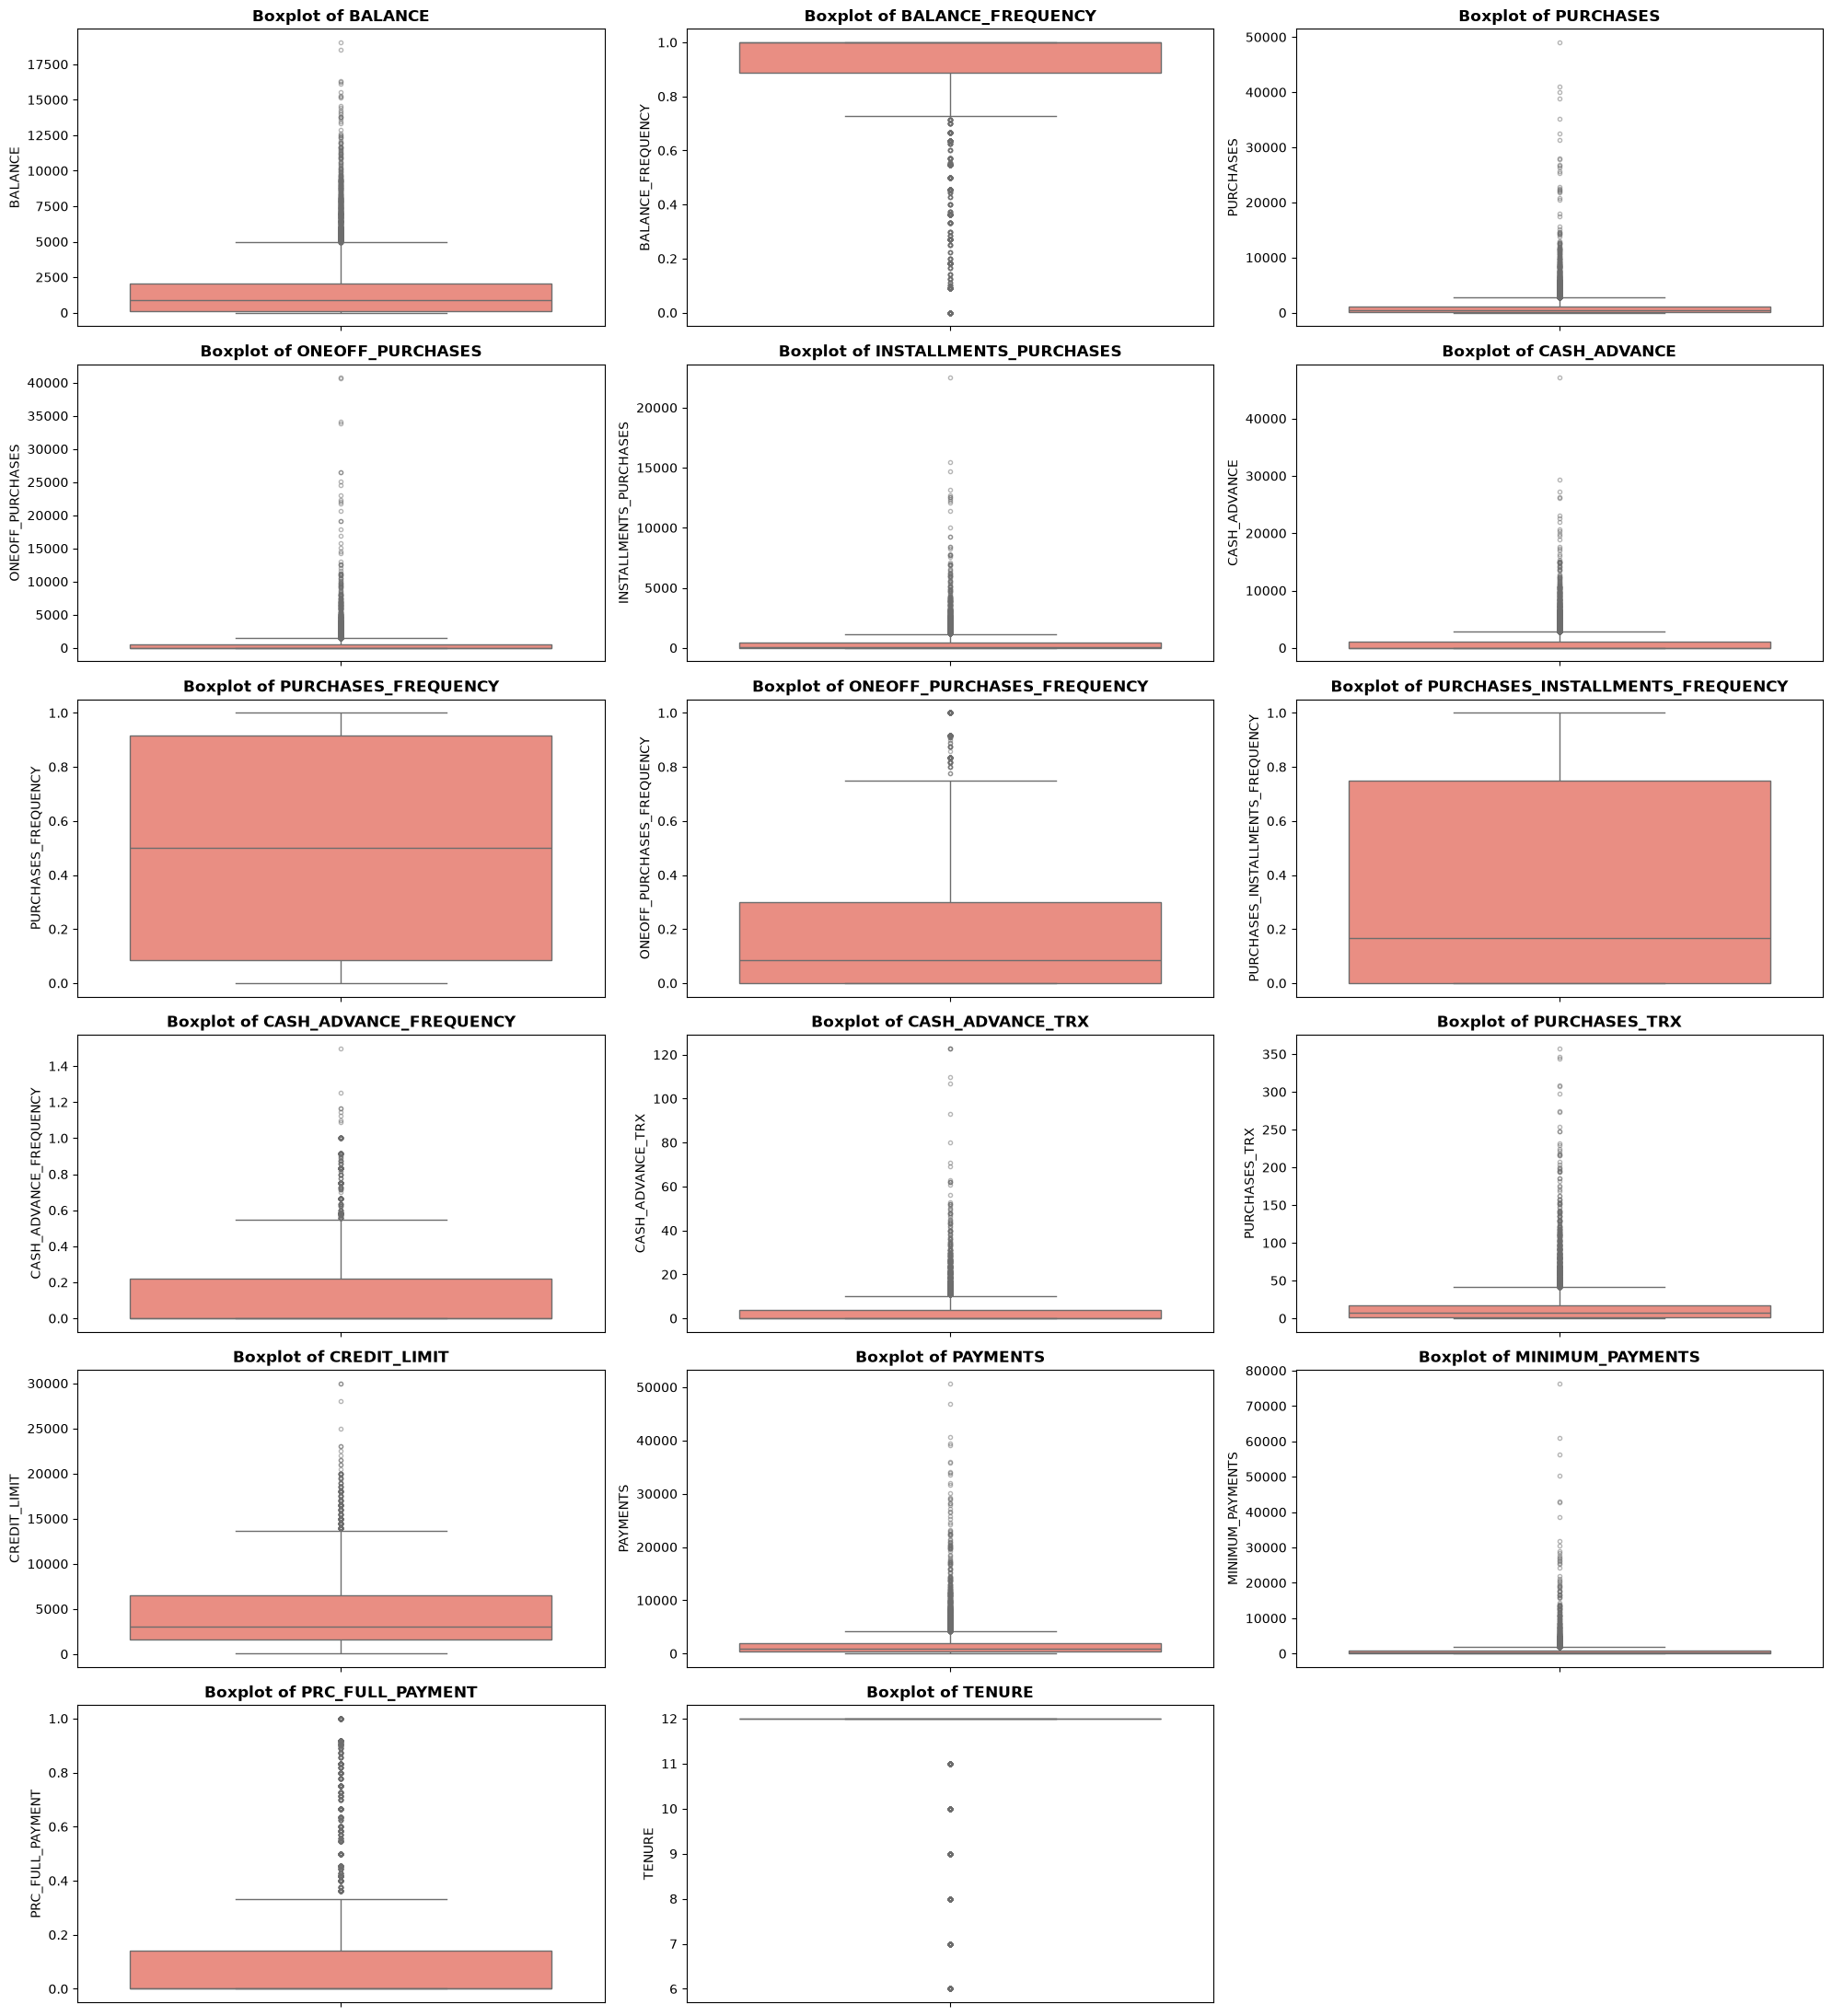

In [12]:
# Box plots to identify outliers and IQR spread for each feature
plt.figure(figsize=(20, 22))

for i, col in enumerate(cols, 1):
    plt.subplot(6, 3, i)
    sns.boxplot(y=df[col], color='salmon', flierprops=dict(marker='o', markersize=3, alpha=0.5))
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

### 3. Skewness Summary

In [13]:
# Calculate and display skewness for each column
skewness_df = pd.DataFrame({
    'Feature': cols,
    'Skewness': [df[col].skew() for col in cols]
}).sort_values(by='Skewness', ascending=False).reset_index(drop=True)

skewness_df

,Feature,Skewness
0,MINIMUM_PAYMENTS,13.866771
1,ONEOFF_PURCHASES,10.044622
2,PURCHASES,8.143969
3,INSTALLMENTS_PURCHASES,7.298823
4,PAYMENTS,5.907465
5,CASH_ADVANCE_TRX,5.720976
6,CASH_ADVANCE,5.166323
7,PURCHASES_TRX,4.630493
8,BALANCE,2.393270
9,PRC_FULL_PAYMENT,1.942641


### Correlation Heatmap

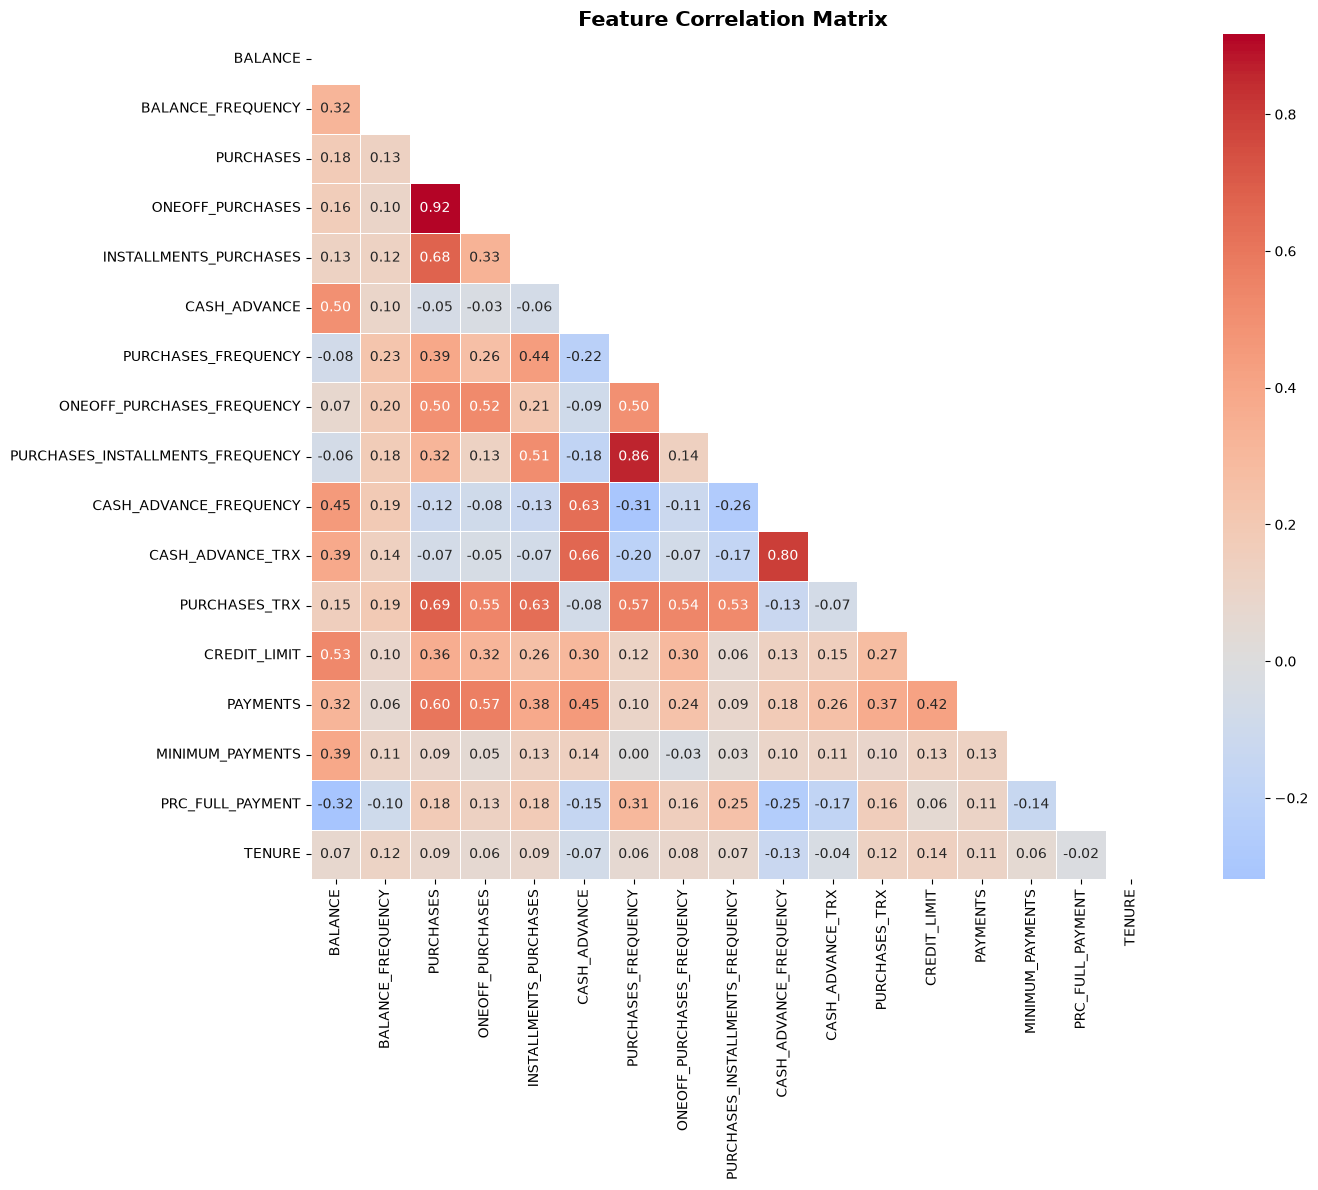

In [14]:
## Correlation Heatmap
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Feature Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Outlier Quantification (IQR method)

In [15]:
## Outlier % per column (IQR method)
outlier_summary = {}
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    outlier_summary[col] = round(len(outliers) / len(df) * 100, 2)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index",
                                     columns=["Outlier %"]).sort_values("Outlier %", ascending=False)
outlier_df

,Outlier %
BALANCE_FREQUENCY,16.67
PRC_FULL_PAYMENT,16.47
TENURE,15.25
CASH_ADVANCE,11.51
ONEOFF_PURCHASES,11.32
INSTALLMENTS_PURCHASES,9.69
PURCHASES,9.03
PAYMENTS,9.03
CASH_ADVANCE_TRX,8.98
ONEOFF_PURCHASES_FREQUENCY,8.74


### Log Transform (Skewed Columns)
We apply `np.log1p()` to highly skewed monetary columns to reduce the effect of extreme outliers and bring the distributions closer to normal before scaling.

In [16]:
## Log-transform highly skewed monetary columns
skewed_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
               "CASH_ADVANCE", "CASH_ADVANCE_TRX", "PURCHASES_TRX",
               "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]

df_transformed = df.copy()
for col in skewed_cols:
    df_transformed[col] = np.log1p(df_transformed[col])

df_transformed.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.818182,4.568506,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,12
1,8.071989,0.909091,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.250000,1.609438,0.000000,8.853808,8.319725,6.978531,0.222222,12
2,7.822504,1.000000,6.651791,6.651791,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,12
3,7.419183,0.636364,7.313220,7.313220,0.000000,5.331694,0.083333,0.083333,0.000000,0.083333,0.693147,0.693147,8.922792,0.000000,6.763082,0.000000,12
4,6.707735,1.000000,2.833213,2.833213,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,12


### Standard Scaling
Scale all features to mean approx 0, std approx 1 using `StandardScaler`.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_transformed),
                          columns=df_transformed.columns)
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205498,-0.249881,-0.113732,-0.987198,0.394362,-0.930636,-0.806649,-0.678716,-0.707409,-0.675294,-0.810038,-0.579693,-1.447095,-0.825080,-0.853732,-0.525588,0.360541
1,0.948821,0.134049,-1.680213,-0.987198,-1.087586,1.528788,-1.221928,-0.678716,-0.917090,0.573949,0.784546,-1.379434,0.925997,1.065109,0.870595,0.234159,0.360541
2,0.824885,0.517980,0.600600,1.061910,-1.087586,-0.930636,1.269742,2.673295,-0.917090,-0.675294,-0.810038,0.487735,1.010161,-0.119646,0.416426,-0.525588,0.360541
3,0.624529,-1.017743,0.827395,1.265665,-1.087586,0.564410,-1.014290,-0.399383,-0.917090,-0.258882,-0.123288,-0.874853,1.010161,-4.163779,0.687881,-0.525588,0.360541
4,0.271106,0.517980,-0.708741,-0.114417,-1.087586,-0.930636,-1.014290,-0.399383,-0.917090,-0.675294,-0.810038,-0.874853,-1.224854,-0.065306,-0.379491,-0.525588,0.360541


#### Verification: confirm mean approx 0, std approx 1

In [18]:
df_scaled.describe().round(3)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000
mean,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.061,-3.705,-1.680,-0.987,-1.088,-0.931,-1.222,-0.679,-0.917,-0.675,-0.810,-1.379,-5.079,-4.164,-5.032,-0.526,-4.127
25%,-0.645,0.049,-0.409,-0.987,-1.088,-0.931,-1.014,-0.679,-0.917,-0.675,-0.810,-0.875,-0.874,-0.423,-0.683,-0.526,0.361
50%,0.304,0.518,0.340,0.141,0.372,-0.931,0.024,-0.399,-0.498,-0.675,-0.810,0.134,-0.108,0.081,-0.113,-0.526,0.361
75%,0.728,0.518,0.725,0.972,0.908,1.037,1.062,0.327,0.970,0.435,0.785,0.725,0.836,0.582,0.688,-0.037,0.361
max,1.834,0.518,2.023,2.283,2.163,2.087,1.270,2.673,1.599,6.820,3.966,2.903,2.701,2.645,4.488,2.893,0.361


## Phase 3 — DBSCAN Tuning

### k-Distance Plot (Find optimal eps)
We compute the 5-nearest-neighbor distances for each point, sort them in descending order, and look for the **elbow** — this is the suggested `eps` value.

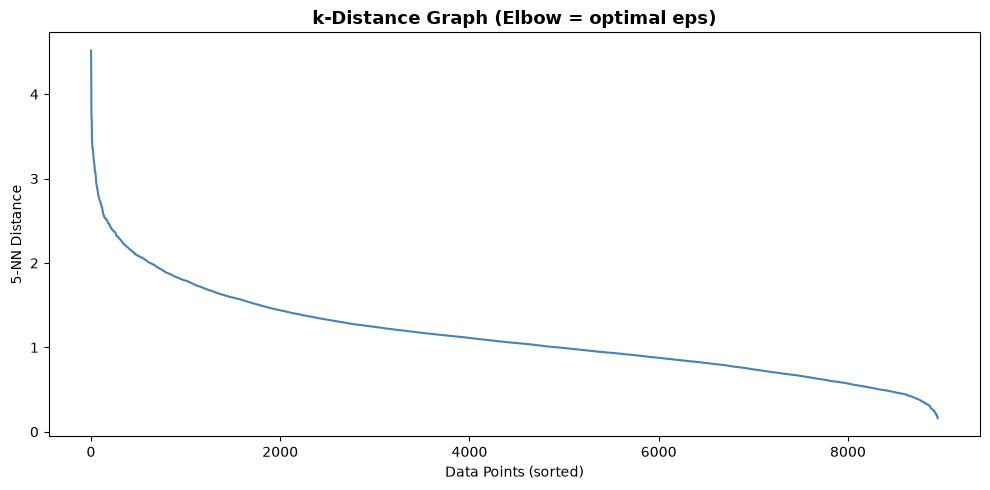

Suggested eps from elbow: 2.75


In [19]:
from sklearn.neighbors import NearestNeighbors

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(df_scaled)
distances, _ = nbrs.kneighbors(df_scaled)
k_distances = np.sort(distances[:, k - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color="steelblue")
plt.xlabel("Data Points (sorted)")
plt.ylabel(f"{k}-NN Distance")
plt.title("k-Distance Graph (Elbow = optimal eps)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Approximate elbow value (used in grid search below)
elbow_idx = int(len(k_distances) * 0.01)  # ~1% of points
suggested_eps = round(k_distances[elbow_idx], 2)
print(f"Suggested eps from elbow: {suggested_eps}")

### Silhouette Grid Search
We sweep over a range of `eps` and `min_samples` values. For each combination that produces 2 or more clusters, we record the **silhouette score**.

In [20]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.arange(0.3, 2.0, 0.1)
min_samples_values = [3, 5, 7, 10]
results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(df_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters >= 2:
            score = silhouette_score(df_scaled, labels, sample_size=2000, random_state=42)
            results.append({"eps": round(eps, 2), "min_samples": ms,
                             "n_clusters": n_clusters, "silhouette": round(score, 4)})

results_df = pd.DataFrame(results).sort_values("silhouette", ascending=False)
print(f"Total valid combinations: {len(results_df)}")
results_df.head(10)

Total valid combinations: 68


,eps,min_samples,n_clusters,silhouette
67,1.9,10,6,0.0428
66,1.9,7,8,-0.0062
51,1.5,10,7,-0.0131
46,1.4,7,9,-0.0247
55,1.6,10,5,-0.0276
63,1.8,10,5,-0.0288
47,1.4,10,7,-0.0374
57,1.7,5,11,-0.0424
65,1.9,5,11,-0.0449
61,1.8,5,12,-0.0499


## Phase 4 — DBSCAN Model

### Final DBSCAN Fit
Using the best `eps` and `min_samples` from the grid search above.

In [21]:
## Fit DBSCAN with best parameters from grid search
best = results_df.iloc[0]
print(f"Best params  -> eps={best['eps']}, min_samples={int(best['min_samples'])}")
print(f"n_clusters   -> {int(best['n_clusters'])}, silhouette -> {best['silhouette']}")

db_final = DBSCAN(eps=best["eps"], min_samples=int(best["min_samples"]))
labels = db_final.fit_predict(df_scaled)

df["Cluster"] = labels
print(f"\nClusters found : {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Noise points   : {(labels == -1).sum()} ({(labels == -1).mean()*100:.1f}%)")

Best params  -> eps=1.9, min_samples=10
n_clusters   -> 6, silhouette -> 0.0428



Clusters found : 6
Noise points   : 613 (6.8%)


## Phase 5 — Evaluation & Visualization

### Silhouette Score

In [22]:
sil_score = silhouette_score(df_scaled, labels)
print(f"Silhouette Score: {sil_score:.4f}")
print("(Range: -1 to 1 — closer to 1 means well-separated, compact clusters)")

Silhouette Score: 0.0515
(Range: -1 to 1 — closer to 1 means well-separated, compact clusters)


### Cluster Size Distribution

C:\Users\abirc\AppData\Local\Temp\ipykernel_15720\887000029.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")


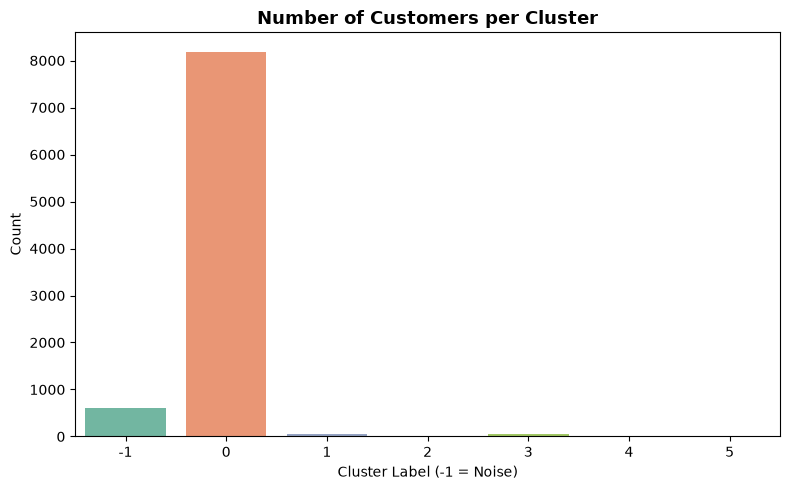

In [23]:
plt.figure(figsize=(8, 5))
cluster_counts = df["Cluster"].value_counts().sort_index()
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")
plt.title("Number of Customers per Cluster", fontsize=13, fontweight="bold")
plt.xlabel("Cluster Label (-1 = Noise)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Cluster Feature Profiles (Mean Values Heatmap)

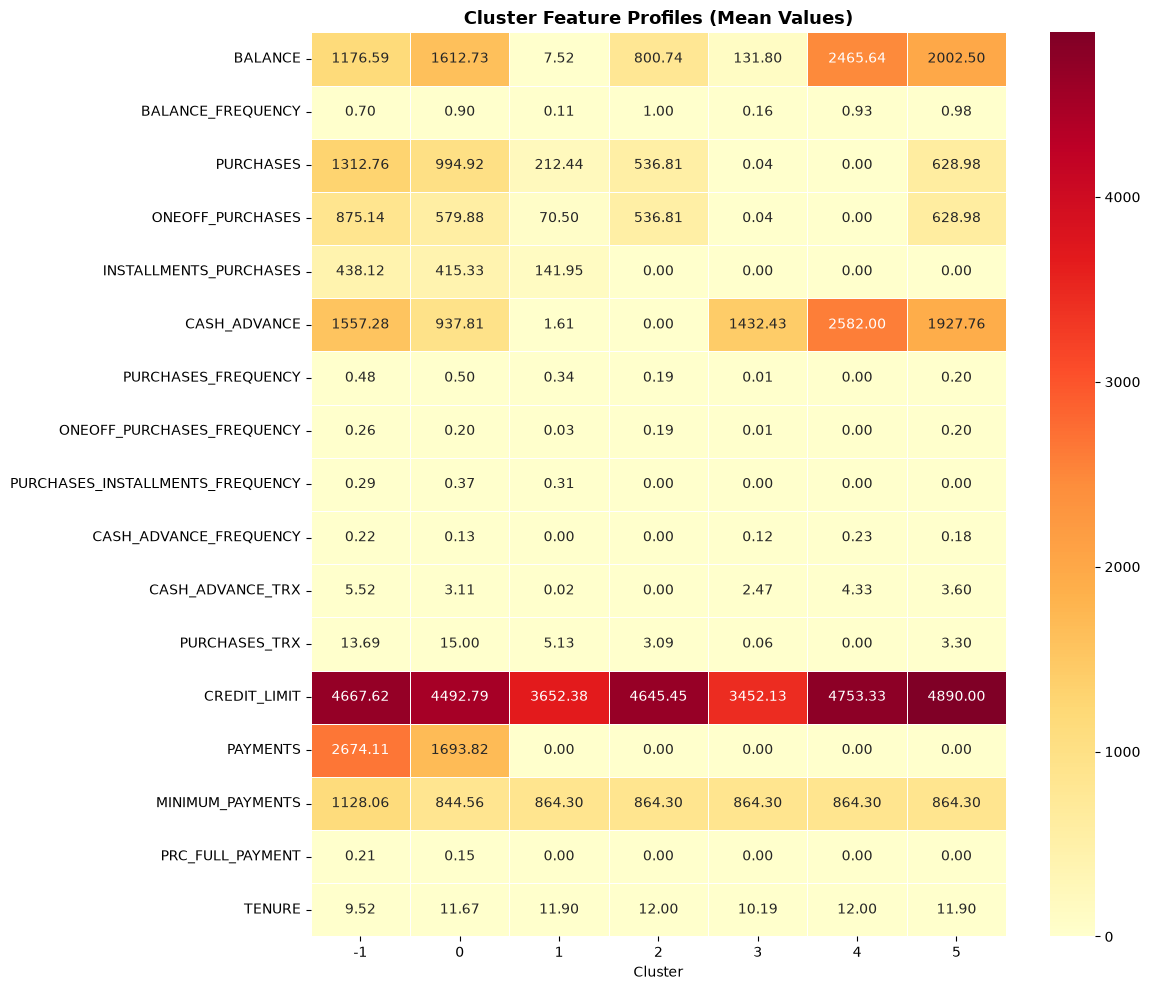

In [24]:
cluster_profile = df.groupby("Cluster").mean().T
plt.figure(figsize=(12, 10))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Cluster Feature Profiles (Mean Values)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2D Scatter — BALANCE vs PURCHASES

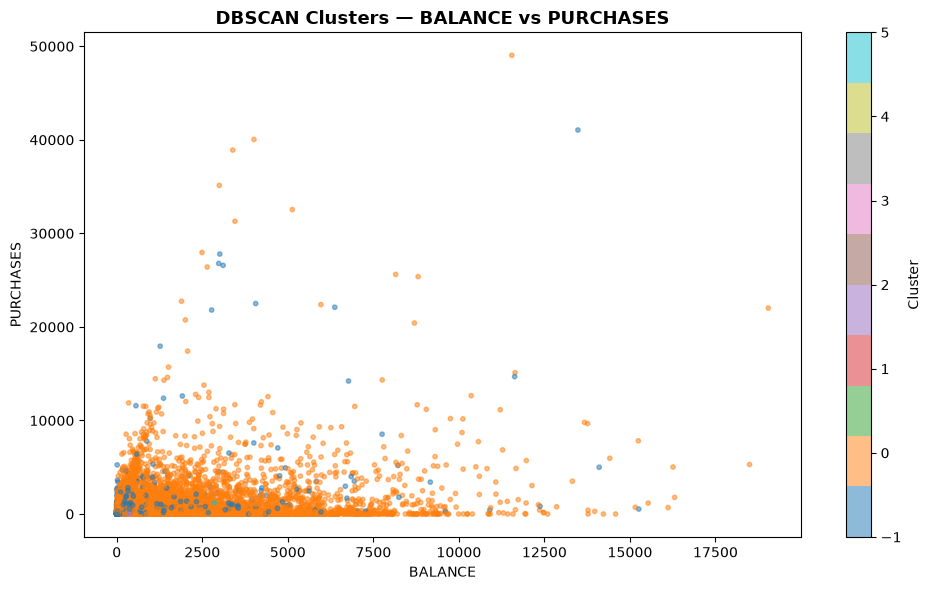

In [25]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["BALANCE"], df["PURCHASES"],
                      c=df["Cluster"], cmap="tab10", alpha=0.5, s=10)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.title("DBSCAN Clusters — BALANCE vs PURCHASES", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()